# ME 323 Module 1 — Choosing the Shear Failure Model
### Faculty notebook (staff only — not for students)

The Module 1 physics layer currently models "shear" failure as **average
shear over the web at bulk yield**, blended with bending through an empirical
inverse-square interaction. The test engineer's fracture notes disagree about
what shear failure *is* in these printed beams: every non-buckling shear-type
failure in 73 tests is a **flange–web separation** — a longitudinal fracture
along the printed interface between the top flange and the web, not a rupture
through the web.

This notebook lays out four candidate shear models, tests them against the
measured failure forces, the fracture notes, and the force–displacement
traces, and recommends one:

> **Recommendation.** Model the shear mode as **shear flow on the flange–web
> junction plane** (the standard built-up-beam "glue-line" check),
> $\tau_j = V Q_f / (I_x\, t_w)$, compared against a **calibrated printed-
> interface strength** $\tau_i \approx 17.5$ MPa (training campaign;
> 11–15 MPa in later print sessions) — *not* bulk yield
> $\sigma_y/\sqrt{3} = 43.9$ MPa. The stress measure is textbook mechanics;
> the strength is a property of the printed interface and can only come from
> test data. Evidence: the implied strength is near-constant across the
> separation failures (CoV 15% vs 41% for the current model), no
> bend-failing beam ever exceeded it, mode identification improves from 89%
> to 93%, and worst-case strength error on the separation beams drops from
> 41% to 18%. A genuine pointwise von Mises formulation was also tested and
> fails the same evidence (Section 5).

Self-contained: loads only committed CSVs from `data/` (GitHub raw, falling
back to a local checkout). Sections: (1) what the notes say, (2) the four
candidates, (3) the back-calculation test, (4) whole-population consistency,
(5) the von Mises objection, (6) force–displacement evidence, (7) predictive
scoring, (8) later batches as validation, (8b) the LTB–separation blur,
(9) recommendation, caveats, and downstream consequences.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

RAW = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/")
def load(name):
    try:
        df = pd.read_csv(RAW + name); src = "GitHub"
    except Exception:
        df = pd.read_csv("../../data/" + name); src = "local copy"
    print(f"{name}: {len(df)} rows ({src})")
    return df

camp   = load("ground_truth_B10_L150.csv")          # 44-beam training campaign
notes  = load("ibeam150_campaign_notes.csv")        # verbatim fracture notes
add    = load("ibeam150_additional_tests.csv")      # 19-beam follow-up batch
sup    = load("ibeam150_support_experiment.csv")    # 10-beam support experiment
traces = load("ibeam150_traces_downsampled.csv")    # campaign F-d traces

camp = camp.merge(notes, on="print_order")

# ---- geometry & physics: identical to ibeam150_common.py / student notebooks ----
B_FLANGE, TH, L_SPAN = 10.0, 18.0, 150.0            # mm
SY, E_MOD = 76e6, 2.5e9                             # Pa
G_MOD, C1_LTB, C2_LTB, K_FIX = E_MOD / 2.6, 1.35, 0.55, 0.33
TAU_Y = SY / np.sqrt(3)                             # bulk shear yield, 43.9 MPa

def section_props(b, H):
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b / 1e3, H / 1e3, B_FLANGE / 1e3, tf / 1e3
    c = (TH / 1e3) / 2.0
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    beta = lambda t, a: 1 - 0.63*(t/a) + 0.052*(t/a)**5
    J = (1/3)*beta(b_, h_)*h_*b_**3 + (2/3)*beta(tf_, B_)*B_*tf_**3
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c, b=b_, h=h_, tf=tf_)

def Q_flange(p):                       # first moment of the flange about the NA
    return (B_FLANGE/1e3) * p["tf"] * (p["h"]/2 + p["tf"]/2)

def Q_na(p):                           # ... plus the half-web, for peak-at-NA
    return Q_flange(p) + p["b"] * (p["h"]/2) * (p["h"]/4)

# the four candidate shear models (failure load in N; V = P/2 in 3-pt bend)
def P_A_avg_web(p):        return 2 * TAU_Y * p["b"] * p["h"]          # current
def P_B_peak_NA(p):        return 2 * TAU_Y * p["Ix"] * p["b"] / Q_na(p)
def P_C_junction_bulk(p):  return 2 * TAU_Y * p["Ix"] * p["b"] / Q_flange(p)
def P_D_junction_cal(p, tau_i): return 2 * tau_i * p["Ix"] * p["b"] / Q_flange(p)

# bending / LTB / interaction, unchanged (needed for the mode competition)
def P_bend(p): return 4 * SY * p["Ix"] / (p["c"] * L_SPAN/1e3)
def P_LTB(p, k=K_FIX):
    My = SY * p["Ix"] / p["c"]
    Lb, zg = k * L_SPAN/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2 * G_MOD * p["J"])/(np.pi**2 * E_MOD * p["Iy"]) + (C2_LTB*zg)**2
    Mcr = C1_LTB * np.pi**2 * E_MOD * p["Iy"]/Lb**2 * (np.sqrt(R) - C2_LTB*zg)
    return 4 * min(My, Mcr) / (L_SPAN/1e3)
def P_interaction(Pb, Ps): return 1.0 / np.sqrt(1/Pb**2 + 1/Ps**2)     # current surrogate

ground_truth_B10_L150.csv: 44 rows (GitHub)
ibeam150_campaign_notes.csv: 44 rows (GitHub)
ibeam150_additional_tests.csv: 19 rows (GitHub)
ibeam150_support_experiment.csv: 10 rows (GitHub)


ibeam150_traces_downsampled.csv: 5720 rows (GitHub)


## 1. What the test engineer saw

Three failure morphologies appear in the notes, and they map onto mechanics
cleanly:

* **"Complete vertical fracture across the center"** — flexural rupture of
  the bottom flange at midspan: the *bend* mode.
* **"Twisted off the test stand / flipped over"** — lateral-torsional
  instability: the *LTB* mode.
* **"Separation of the top flange and the web. No vertical fracture"** — a
  fracture plane running *along the beam* at the flange–web interface. This
  is the campaign's actual "shear" failure, and it is an **interlayer**
  failure along the printed layer lines, which are weaker than solid material, not yielding of the web.

The verbatim notes for every non-bend beam:

In [2]:
print(camp.obs_mode.value_counts().to_string(), "\n")
for _, r in camp[camp.obs_mode != "bend"].sort_values("obs_mode").iterrows():
    print(f"print {r.print_order:2d}  (b={r.b_mm:.2f}, H_web={r.H_web_mm:5.2f})  "
          f"{r.strength_N:6.1f} N  [{r.obs_mode}]\n    \"{r.failure_note}\"")

obs_mode
bend              37
flange_web_sep     5
LTB                2 

print  1  (b=1.25, H_web= 5.00)   641.1 N  [LTB]
    "Twisted off the test stand and flipped over"
print 35  (b=1.75, H_web=15.80)   314.4 N  [LTB]
    "Twisted off the test stand and flipped over"
print  3  (b=1.25, H_web=16.00)   226.2 N  [flange_web_sep]
    "Seperation of the top flange and the web. No vertical fracture"
print  9  (b=1.25, H_web=10.50)   701.0 N  [flange_web_sep]
    "Seperation of the top flange and the web. No vertical fracture. Piece of the web along the center of the beam also broke off."
print 30  (b=2.15, H_web= 6.90)   865.2 N  [flange_web_sep]
    "Seperation of the top flange and the web. No vertical fracture"
print 40  (b=1.50, H_web= 5.00)   790.0 N  [flange_web_sep]
    "Seperation of the top flange and the web. No vertical fracture"
print 44  (b=1.40, H_web=10.40)   654.6 N  [flange_web_sep]
    "Seperation of the top flange and the web. No vertical fracture"


The separations cluster on the thin-web frontier (b ≤ 2.15 mm). Note also the
mixed cases inside the "bend" pool — e.g. print 14's note reads *"Fracture
vertically as well as complete seperation of the top flange and the web"* —
they will reappear later as the boundary cases the model should (and does)
place right at the threshold.

## 2. The four candidate shear models

All are checks of the transverse shear force $V = P/2$ against a strength;
they differ in **which plane** carries the critical stress and **which
material strength** that plane is allowed.

**Model A — average web shear at bulk yield** (the current `P_shear`):

$$\tau_{avg} = \frac{V}{t_w h_w} \;\le\; \frac{\sigma_y}{\sqrt{3}}
\qquad\Rightarrow\qquad P_A = 2\,\frac{\sigma_y}{\sqrt{3}}\,t_w h_w$$

Assumes the web yields uniformly (the plastic-design idealization). In the
class model this feeds the empirical interaction surrogate
$P_{int} = (P_{bend}^{-2} + P_A^{-2})^{-1/2}$.

**Model B — peak elastic shear at the neutral axis, bulk yield** (the
textbook $VQ/It$ maximum):

$$\tau_{NA} = \frac{V\,Q_{NA}}{I_x t_w},\quad
Q_{NA} = Q_f + \frac{t_w h_w^2}{8}
\qquad\Rightarrow\qquad P_B = 2\,\frac{\sigma_y}{\sqrt{3}}\,\frac{I_x t_w}{Q_{NA}}$$

**Model C — shear flow on the flange–web junction plane, bulk yield.** The
glue-line check for built-up members: the longitudinal shear the joint must
transmit is $q = V Q_f / I_x$ with $Q_f$ the first moment of the *flange
alone*; the joint plane has width $t_w$ (only the middle $t_w$ of the flange
face is attached to the web):

$$\tau_j = \frac{V\,Q_f}{I_x t_w},\quad
Q_f = B\,t_f\,\frac{h_w + t_f}{2}
\qquad\Rightarrow\qquad P_C = 2\,\frac{\sigma_y}{\sqrt{3}}\,\frac{I_x t_w}{Q_f}$$

**Model D (recommended) — same stress measure as C, calibrated interface
strength.** The plane that actually fractured is a printed interlayer joint;
its strength is not a handbook number and must be calibrated from tests:

$$P_D = 2\,\tau_i\,\frac{I_x t_w}{Q_f}, \qquad \tau_i \;\text{fit from the
observed separation failures}$$

For these thin-web sections $Q_{NA}$ exceeds $Q_f$ by only ~4–8% (the web
contributes little), so B and C/D share nearly the same *geometry scaling*
— the real discriminators are (i) A's very different scaling and (ii) the
strength value. Note the theory also says where bulk shear yield would have
to happen — mid-web, Model B's plane — and **no beam ever ruptured there**:
as Section 3 shows, no campaign beam ever reached even half of
$\sigma_y/\sqrt{3}$ anywhere in its web.

## 3. The back-calculation test

The logic: a failure model is (stress measure) ≤ (one material strength). If
the stress measure is right, then evaluating it *at each measured failure
load* should return **the same strength for every separation beam** — they
all broke the same joint. A measure that returns wildly different "strengths"
for different geometries scales wrongly with geometry. The scorecard is the
coefficient of variation (CoV = std/mean) of the implied strength.

In [3]:
def implied_taus(b, H, P_N):
    p = section_props(b, H); V = P_N / 2.0
    return (V / (p["b"]*p["h"]) / 1e6,
            V * Q_na(p) / (p["Ix"]*p["b"]) / 1e6,
            V * Q_flange(p) / (p["Ix"]*p["b"]) / 1e6)

camp[["tau_avg", "tau_NA", "tau_j"]] = [
    implied_taus(r.b_mm, r.H_web_mm, r.strength_N) for _, r in camp.iterrows()]

sep = camp[camp.obs_mode == "flange_web_sep"]
print("implied shear stress AT FAILURE (MPa) — separation beams "
      f"(bulk yield would be {TAU_Y/1e6:.1f}):\n")
print(sep[["print_order", "b_mm", "H_web_mm", "strength_N",
           "tau_avg", "tau_NA", "tau_j"]].round(2).to_string(index=False))

core = sep[sep.print_order != 3]      # print 3 excluded -- LTB-governed, see below
print("\nconstancy across the four clean separations (excl. print 3):")
for c, lbl in [("tau_avg", "A  avg web     "), ("tau_NA", "B  peak at NA  "),
               ("tau_j",   "C/D junction   ")]:
    v = core[c]
    print(f"  {lbl}: mean {v.mean():6.2f} MPa   CoV {100*v.std(ddof=1)/v.mean():5.1f}%   "
          f"range {v.min():5.2f}-{v.max():5.2f}")
TAU_I = core.tau_j.mean() * 1e6
print(f"\ncalibrated interface strength tau_i = {TAU_I/1e6:.2f} MPa "
      f"= {TAU_I/TAU_Y:.2f} x bulk shear yield")

implied shear stress AT FAILURE (MPa) — separation beams (bulk yield would be 43.9):

 print_order  b_mm  H_web_mm  strength_N  tau_avg  tau_NA  tau_j
           3  1.25      16.0       226.2     5.65    6.04   4.11
           9  1.25      10.5       701.0    26.70   19.86  18.66
          30  2.15       6.9       865.2    29.16   15.52  14.97
          40  1.50       5.0       790.0    52.67   20.89  20.63
          44  1.40      10.4       654.6    22.48   16.65  15.56

constancy across the four clean separations (excl. print 3):
  A  avg web     : mean  32.75 MPa   CoV  41.4%   range 22.48-52.67
  B  peak at NA  : mean  18.23 MPa   CoV  14.0%   range 15.52-20.89
  C/D junction   : mean  17.45 MPa   CoV  15.3%   range 14.97-20.63

calibrated interface strength tau_i = 17.45 MPa = 0.40 x bulk shear yield


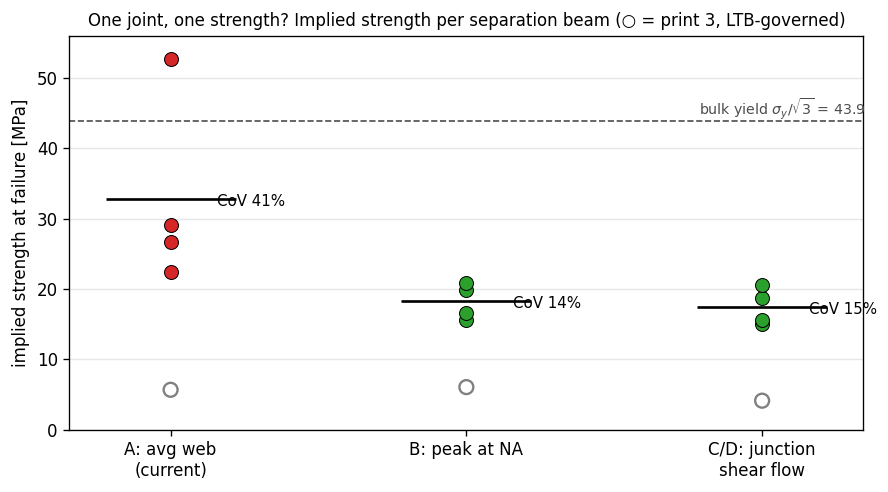

In [4]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
meas = [("tau_avg", "A: avg web\n(current)"), ("tau_NA", "B: peak at NA"),
        ("tau_j", "C/D: junction\nshear flow")]
for i, (c, lbl) in enumerate(meas):
    v, v3 = core[c], sep.loc[sep.print_order == 3, c]
    ax.scatter([i]*len(v), v, s=70, zorder=3,
               c="tab:red" if c == "tau_avg" else "tab:green", edgecolor="k", lw=0.6)
    ax.scatter([i], v3, s=70, zorder=3, facecolor="none", edgecolor="0.5", lw=1.4)
    ax.hlines(v.mean(), i-0.22, i+0.22, color="k", lw=1.6, zorder=4)
    ax.annotate(f"CoV {100*v.std(ddof=1)/v.mean():.0f}%", (i, v.mean()),
                xytext=(28, -4), textcoords="offset points", fontsize=9)
ax.axhline(TAU_Y/1e6, color="0.3", ls="--", lw=1)
ax.text(2.35, TAU_Y/1e6 + 0.8, "bulk yield $\\sigma_y/\\sqrt{3}$ = 43.9",
        fontsize=8.5, ha="right", color="0.3")
ax.set_xticks(range(3), [l for _, l in meas])
ax.set_ylabel("implied strength at failure [MPa]")
ax.set_title("One joint, one strength? Implied strength per separation beam "
             "(○ = print 3, LTB-governed)", fontsize=10)
ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 56)
plt.tight_layout(); plt.show()

The junction measure returns 15.0–20.6 MPa for all four clean separations
(CoV 15%); the current average-web measure returns 22–53 MPa (CoV 41%) — it
scales wrongly with geometry (compare print 40, a stubby thick-flanged
section, against print 9, a tall thin one). And the strength itself is ~0.4×
bulk: the printed interface, not PLA, is what fails.

**Why print 3 is excluded from the calibration.** Print 3 (b = 1.25,
H_web = 16, t_f = 1 mm) sits in the LTB corner; it failed at 226 N with an
implied junction stress of only 4.1 MPa. If the interface were that weak,
prints 9/40/44 could never have reached 15–21 MPa. What the note records is
the *fracture path*: the beam twisted (LTB sets the load), and the twisting
pried the 1 mm flange off the web — a different load path than the
longitudinal shear flow this model checks. The mode competition in Section 7
assigns it to LTB. Its neighbor print 35 (b = 1.75, H = 15.8, "twisted off
the stand") is the same story told in reverse: the note says LTB and the
model agrees. Section 8b quantifies this blur band — twist margins for every
separation and LTB across all batches — and shows the calibration is robust
to it.

## 4. Does the rest of the population cooperate?

A calibrated strength earns trust only if the beams that did **not** separate
stayed below it. Every one of the 37 bend-failing beams must have carried a
junction stress *under* $\tau_i$ at its (higher, bend-governed) failure load
— otherwise the model would have falsely predicted separation.

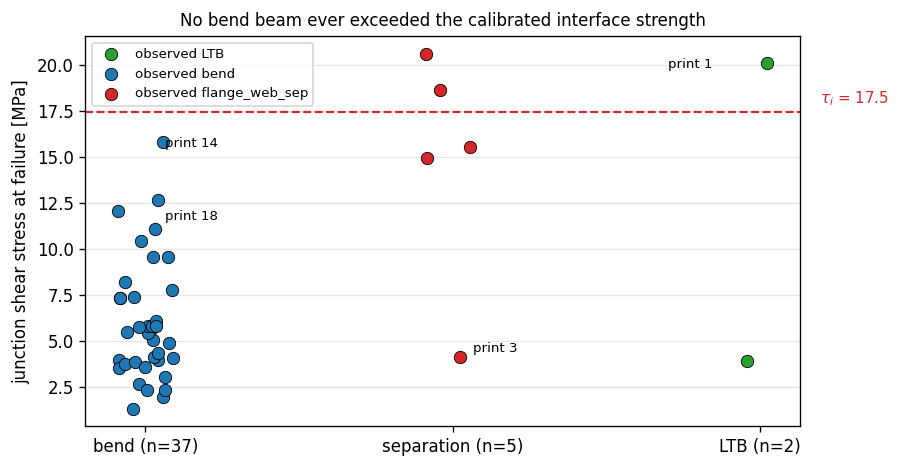

max junction stress among bend beams: 15.8 MPa (print 14) < tau_i = 17.5
bend beams above tau_i: 0 of 37


In [5]:
bend = camp[camp.obs_mode == "bend"]
fig, ax = plt.subplots(figsize=(7.6, 4.0))
jit = np.random.default_rng(0).uniform(-0.09, 0.09, len(camp))
XPOS = {"bend": 0, "flange_web_sep": 1, "LTB": 2}
COL = {"bend": "tab:blue", "flange_web_sep": "tab:red", "LTB": "tab:green"}
for m, g in camp.groupby("obs_mode"):
    ax.scatter(np.full(len(g), XPOS[m]) + jit[:len(g)], g.tau_j, s=55,
               c=COL[m], edgecolor="k", lw=0.5, zorder=3, label=f"observed {m}")
ax.axhline(TAU_I/1e6, color="tab:red", ls="--", lw=1.3)
ax.text(2.42, TAU_I/1e6 + 0.5, f"$\\tau_i$ = {TAU_I/1e6:.1f}", color="tab:red", fontsize=9, ha="right")
for po, dx, dy in [(14, 12, -3), (18, 12, -12), (3, 12, 3), (1, -55, -3)]:
    r = camp[camp.print_order == po].iloc[0]
    ax.annotate(f"print {po}", (XPOS[r.obs_mode], r.tau_j),
                xytext=(dx, dy), textcoords="offset points", fontsize=8)
ax.set_xticks(range(3), ["bend (n=37)", "separation (n=5)", "LTB (n=2)"])
ax.set_ylabel("junction shear stress at failure [MPa]")
ax.set_title("No bend beam ever exceeded the calibrated interface strength", fontsize=10)
ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()
print(f"max junction stress among bend beams: {bend.tau_j.max():.1f} MPa "
      f"(print {int(bend.loc[bend.tau_j.idxmax(), 'print_order'])}) < tau_i = {TAU_I/1e6:.1f}")
print(f"bend beams above tau_i: {(bend.tau_j > TAU_I/1e6).sum()} of {len(bend)}")

Zero violations in 37 bend beams — and the two closest approaches are
exactly the beams whose notes flag partial separation: print 14 (15.8 MPa,
*"fracture vertically as well as complete seperation…"*) and print 18
(12.7 MPa, the geometry whose later reprints straddle both modes — Section
8). The boundary cases land at the boundary; that is what a correct model
looks like from the other side.

Two honest notes. First, print 1 (b = 1.25, H = 5) "twisted off the test
stand" at an implied junction stress of 20.1 MPa — at the top of the
separation band. LTB is not credible for a 5 mm web (the yield cap binds),
so we read it as a fixture event that interrupted a beam already at
interface capacity; either way it is no counterexample to $\tau_i$. Second,
a recalibrated Model A (fit its own strength to the same four beams) would
also "separate" the training population — but its implied strength has CoV
41% and its fitted value fails on the later batches (Section 8). Constancy,
not classification alone, is what discriminates.

## 5. The obvious objection: what about von Mises?

Two different things have carried that name in this project, so we answer
both. The **legacy `P_vm`** in the pipeline code is the inverse-square blend
$(P_{bend}^{-2} + P_A^{-2})^{-1/2}$ — a smooth interaction *surrogate*, not
a pointwise stress criterion, which is why it was renamed `P_int` in the
2026-07-15 terminology cleanup. It is the "current model" baseline scored in
Section 7.

The **genuine pointwise criterion** is the serious objection. At the
midspan section, bending stress and shear flow peak *simultaneously*
($M = PL/4$ and $V = P/2$ act at the same cut), so the textbook refinement
for a ductile I-beam is to check

$$\sigma_{vM}(y) = \sqrt{\sigma^2 + 3\tau^2},\qquad
\sigma = \frac{M\,y}{I_x},\quad \tau = \frac{V\,Q(y)}{I_x\,t_w},$$

maximized over the web ($Q = Q_f$ at the junction $y = h_w/2$, where
$\sigma$ is also largest — the classic critical point). We test it both
ways it could be used — against bulk yield, and against a calibrated
strength — with the same two tests as Models A–D.

In [6]:
def sigma_junction(b, H, P):                 # bending stress at y = h/2, MPa
    p = section_props(b, H)
    return (P * (L_SPAN/1e3)/4) * (p["h"]/2) / p["Ix"] / 1e6

def vm_max_over_web(b, H, P):                # max von Mises over the web, MPa
    p = section_props(b, H)
    M, V = P * (L_SPAN/1e3)/4, P/2
    ys = np.linspace(0, p["h"]/2, 60)
    Q = Q_flange(p) + p["b"] * ((p["h"]/2)**2 - ys**2) / 2
    vm = np.sqrt((M*ys/p["Ix"])**2 + 3*(V*Q/(p["Ix"]*p["b"]))**2)
    return vm.max() / 1e6

camp["sig_j"] = [sigma_junction(r.b_mm, r.H_web_mm, r.strength_N) for _, r in camp.iterrows()]
camp["vm_j"] = np.sqrt(camp.sig_j**2 + 3*camp.tau_j**2)
sepv = camp[camp.obs_mode == "flange_web_sep"]
corev = sepv[sepv.print_order != 3]
bendv = camp[camp.obs_mode == "bend"]

print("TEST 1 — constancy across the 4 clean separations (implied strength, MPa):")
for c, lbl in [("tau_j", "pure junction shear (D)   "),
               ("vm_j",  "pointwise vM at junction  "),
               ("sig_j", "bending stress at junction")]:
    v = corev[c]
    print(f"  {lbl}: mean {v.mean():6.2f}  CoV {100*v.std(ddof=1)/v.mean():5.1f}%  "
          f"range {v.min():.1f}-{v.max():.1f}")

# variant 1: bulk yield. Where does the web vM check bind, relative to flexure?
grid_ratio = min(SY/1e6 / vm_max_over_web(b, H, P_bend(section_props(b, H)))
                 for b in np.linspace(1.25, 7.0, 40) for H in np.linspace(5.0, 16.0, 40))
print(f"\nvariant 1, bulk yield: min over the design box of P_vM-web / P_bend = "
      f"{grid_ratio:.2f}")
print("  -> the web vM check NEVER governs; the model degenerates to flexure-only.")
print("     measured / vM-bulk prediction for the separation beams:")
for _, r in sepv.iterrows():
    Pp = (SY/1e6) / vm_max_over_web(r.b_mm, r.H_web_mm, 1.0)
    print(f"       print {r.print_order:2d}: {r.strength_N/Pp:.2f}")

# variant 2: calibrated strength, same fit as tau_i (mean over the 4 clean seps)
thr_vm = corev.vm_j.mean()
n_vm, n_tau = (bendv.vm_j > thr_vm).sum(), (bendv.tau_j > TAU_I/1e6).sum()
print(f"\nvariant 2, calibrated: vM strength = {thr_vm:.1f} MPa (fit on the same 4 beams)")
print(f"TEST 2 — bend beams exceeding the calibrated threshold WITHOUT separating:")
print(f"  pure junction shear tau_i : {n_tau} of {len(bendv)}")
print(f"  pointwise vM at junction  : {n_vm} of {len(bendv)}")
print("\n  worst offenders (all failed in bending, none separated):")
print(bendv.nlargest(6, "vm_j")[["print_order", "b_mm", "H_web_mm", "strength_N",
                                  "sig_j", "tau_j", "vm_j"]].round(1).to_string(index=False))

TEST 1 — constancy across the 4 clean separations (implied strength, MPa):
  pure junction shear (D)   : mean  17.45  CoV  15.3%  range 15.0-20.6
  pointwise vM at junction  : mean  40.74  CoV  12.2%  range 35.4-47.2
  bending stress at junction: mean  26.37  CoV  32.0%  range 15.5-34.4

variant 1, bulk yield: min over the design box of P_vM-web / P_bend = 1.10
  -> the web vM check NEVER governs; the model degenerates to flexure-only.
     measured / vM-bulk prediction for the separation beams:
       print  3: 0.49
       print  9: 0.62
       print 30: 0.47
       print 40: 0.51
       print 44: 0.55

variant 2, calibrated: vM strength = 40.7 MPa (fit on the same 4 beams)
TEST 2 — bend beams exceeding the calibrated threshold WITHOUT separating:
  pure junction shear tau_i : 0 of 37
  pointwise vM at junction  : 18 of 37

  worst offenders (all failed in bending, none separated):
 print_order  b_mm  H_web_mm  strength_N  sig_j  tau_j  vm_j
           4   7.0      16.0       829.4   

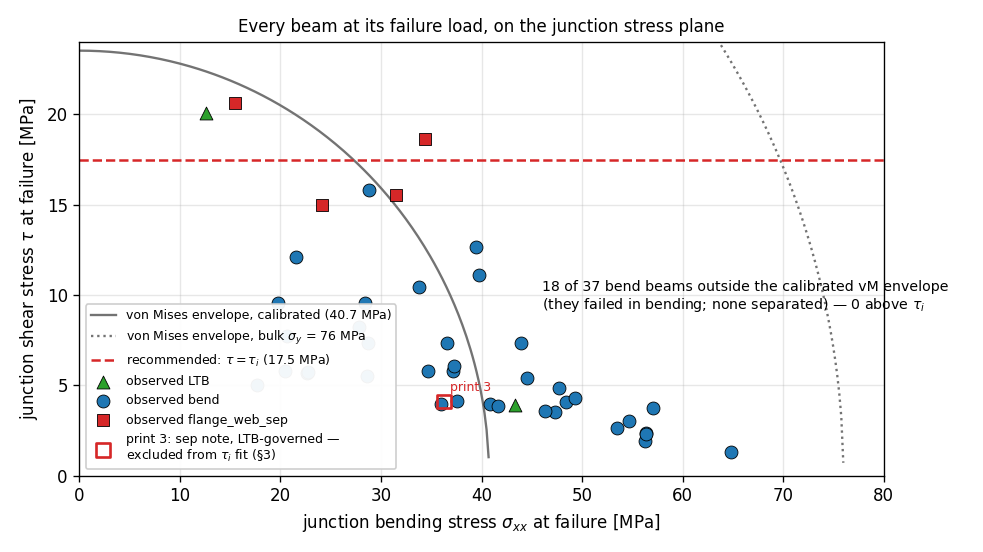

In [ ]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
sg = np.linspace(0, 80, 400)
for R, ls, lbl in [(thr_vm, "-", f"von Mises envelope, calibrated ({thr_vm:.1f} MPa)"),
                   (SY/1e6, ":", "von Mises envelope, bulk $\\sigma_y$ = 76 MPa")]:
    tt = np.sqrt(np.clip(R**2 - sg**2, 0, None) / 3)
    ax.plot(sg[tt > 0], tt[tt > 0], color="0.45", ls=ls, lw=1.4, label=lbl)
ax.axhline(TAU_I/1e6, color="tab:red", ls="--", lw=1.5,
           label=f"recommended: $\\tau = \\tau_i$ ({TAU_I/1e6:.1f} MPa)")
MK5 = {"bend": "o", "flange_web_sep": "s", "LTB": "^"}
for m, g in camp.groupby("obs_mode"):
    if m == "flange_web_sep":
        g = g[g.print_order != 3]
    ax.scatter(g.sig_j, g.tau_j, c=COL[m], marker=MK5[m], s=60,
               edgecolor="k", lw=0.5, zorder=3, label=f"observed {m}")
p3 = camp[camp.print_order == 3].iloc[0]
ax.scatter([p3.sig_j], [p3.tau_j], facecolor="none", edgecolor=COL["flange_web_sep"],
           marker="s", s=70, lw=1.6, zorder=3,
           label="print 3: sep note, LTB-governed —\nexcluded from $\\tau_i$ fit (§3)")
ax.annotate("print 3", (p3.sig_j, p3.tau_j), xytext=(4, 6),
            textcoords="offset points", fontsize=7.5, color="tab:red")
ax.annotate(f"{n_vm} of {len(bendv)} bend beams outside the calibrated vM envelope\n"
            f"(they failed in bending; none separated) — {n_tau} above $\\tau_i$",
            (46, 9.2), fontsize=8.5, ha="left")
ax.set_xlabel("junction bending stress $\\sigma_{xx}$ at failure [MPa]")
ax.set_ylabel("junction shear stress $\\tau$ at failure [MPa]")
ax.set_title("Every beam at its failure load, on the junction stress plane", fontsize=10)
ax.set_xlim(0, 80); ax.set_ylim(0, 24)
ax.grid(alpha=0.3); ax.legend(fontsize=7.5, loc="lower left", framealpha=0.95)
plt.tight_layout(); plt.show()

**Verdict, variant by variant.** Against **bulk yield**, the pointwise vM
check never governs anywhere in the design box (the web check sits ≥ 1.1×
flexure everywhere), so the "full" vM model is numerically the flexure-only
model — already the worst physics entry in the campaign ablation (21.3%
LOOCV MAPE) — it predicts *zero* separations while five beams separated,
and over-predicts the five separation loads by 1.6–2.1×.

Against a **calibrated strength**, the constancy test alone cannot reject
it: CoV 12% on four points, statistically indistinguishable from the pure
shear measure's 15% (it even absorbs print 3 into family — a caution about
how a flexible wrong model can swallow an outlier). The population test is
what discriminates, decisively: **18 of 37 bend beams exceeded the
calibrated vM envelope without separating** (worst: print 4 at 64.9 MPa vs
the 40.7 threshold) — every tall-web, thin-flange beam whose junction
bending stress is large — versus **zero** violations for the pure-shear
criterion. Those 18 beams are the experiment answering the question
directly: *the interface does not feel* $\sigma_{xx}$.

The mechanics says the same thing. The failing plane is horizontal; the
traction it carries is the longitudinal shear $\tau_{xy}$ (plus
$\sigma_{yy} \approx 0$ away from the load nose, compressive under it).
$\sigma_{xx}$ acts *parallel* to the plane — it can neither pull it apart
nor slide it. Von Mises is an isotropic *yield* criterion: it asks whether
the bulk flows, using stress invariants. Decohesion of a weak plane asks a
different question — whether the traction *on that plane* exceeds the
plane's strength — and only $\tau$ appears in it. This is precisely why
wood and laminated-composite design check delamination with an
interlaminar shear allowable rather than von Mises. Dropping $\sigma$ from
the criterion is not a simplification of von Mises; it is the correct
criterion for the observed failure, and the figure above is its
experimental confirmation.

Von Mises still lives where it belongs: the $\sigma_y/\sqrt{3}$ in Models
A–C *is* the von Mises pure-shear yield, the bend mode is the von Mises
criterion at the extreme fiber, and for a homogeneous ductile I-beam the
junction vM check would be the right refinement. Our printed beams violate
its isotropy assumption on one specific plane — which is exactly the
module's lesson about printed parts.

## 6. What the force–displacement traces add

The $VQ/It$ distribution is an *elastic* stress field, so the model is only
self-consistent if separation beams are still near-linear at peak. Measure:
tangent stiffness late in the rise (80–97% of peak) relative to the initial
slope (20–60%).

late/initial tangent stiffness at peak (1.0 = linear to failure):

                mean   min   max  count
obs_mode                               
LTB             0.78  0.72  0.84      2
bend            0.58  0.51  0.67     37
flange_web_sep  0.74  0.63  0.87      5


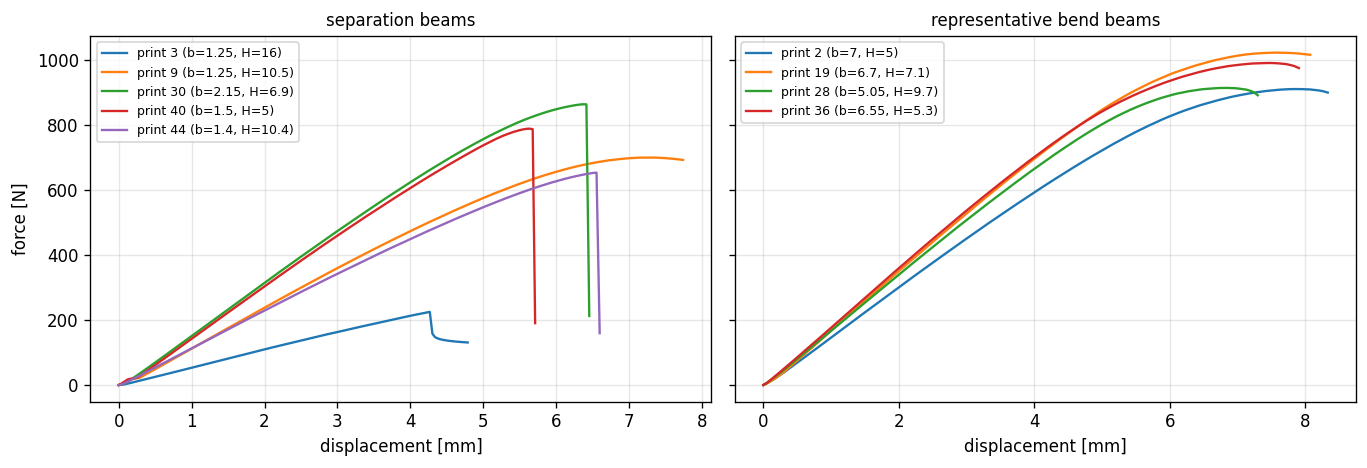

In [8]:
def shape_ratio(g):
    Fmax = g.F_N.max(); ipk = int(g.F_N.idxmax())
    rise = g.loc[:ipk]
    w1 = rise[(rise.F_N >= .20*Fmax) & (rise.F_N <= .60*Fmax)]
    w2 = rise[(rise.F_N >= .80*Fmax) & (rise.F_N <= .97*Fmax)]
    if len(w1) < 3 or len(w2) < 3: return np.nan
    return np.polyfit(w2.d_mm, w2.F_N, 1)[0] / np.polyfit(w1.d_mm, w1.F_N, 1)[0]

camp["k_ratio"] = [shape_ratio(traces[traces.print_order == po].reset_index(drop=True))
                   for po in camp.print_order]
print("late/initial tangent stiffness at peak (1.0 = linear to failure):\n")
print(camp.groupby("obs_mode").k_ratio.agg(["mean", "min", "max", "count"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
for ax, pos, ttl in [(axes[0], sep.print_order, "separation beams"),
                     (axes[1], [2, 19, 28, 36], "representative bend beams")]:
    for po in pos:
        g = traces[traces.print_order == po]
        r = camp[camp.print_order == po].iloc[0]
        ax.plot(g.d_mm, g.F_N, lw=1.4,
                label=f"print {po} (b={r.b_mm:g}, H={r.H_web_mm:g})")
    ax.set_xlabel("displacement [mm]"); ax.grid(alpha=0.3)
    ax.legend(fontsize=7.5); ax.set_title(ttl, fontsize=10)
axes[0].set_ylabel("force [N]")
plt.tight_layout(); plt.show()

Separation beams run 0.63–0.87 of their initial stiffness at peak — stiffer
at failure than the bend population (0.51–0.67), which visibly yields before
rupturing. The elastic distribution is a reasonable approximation for the
separation mode (the residual softening also includes seating and
load-point indentation, so 0.7–0.9 understates linearity). Post-peak shape
is *not* usable evidence either way: the Instron's break-detection truncates
most bend traces at the drop, so brittleness comparisons would be an
artifact of test-stop settings.

## 7. Does the better theory predict better?

Two checks: mode identification (which failure mode governs each design) and
strength accuracy on the separation beams. "Old" = current class physics,
min($P_{int}$, $P_{LTB}$) with mode from min($P_{bend}$, $P_A$, $P_{LTB}$);
"new" = min($P_{bend}$, $P_D$, $P_{LTB}$), same bending and LTB throughout
(k = 0.33).

In [9]:
def gov_old(b, H):
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p), P_A_avg_web(p), P_LTB(p)
    cap = min(P_interaction(Pb, Ps), Pl)
    gov = "sep" if Ps < min(Pb, Pl) else ("LTB" if Pl < 0.999*Pb else "bend")
    return cap, gov

def gov_new(b, H):
    p = section_props(b, H)
    Pb, Pd, Pl = P_bend(p), P_D_junction_cal(p, TAU_I), P_LTB(p)
    cap = min(Pb, Pd, Pl)
    gov = "sep" if Pd == cap else ("LTB" if Pl < 0.999*Pb else "bend")
    return cap, gov

MATCH = {"bend": {"bend"}, "LTB": {"LTB"}, "flange_web_sep": {"sep"}}
for name, fn in [("old", gov_old), ("new", gov_new)]:
    pred = [fn(b, H)[1] for b, H in camp[["b_mm", "H_web_mm"]].values]
    ok = [p in MATCH[o] for p, o in zip(pred, camp.obs_mode)]
    print(f"{name}: {100*np.mean(ok):.0f}% of the 44 notes matched")
    camp[f"pred_{name}"], camp[f"ok_{name}"] = pred, ok
print("\nconfusion, new model (rows = observed):")
print(pd.crosstab(camp.obs_mode, camp.pred_new))
print("\nremaining misses (new):")
for _, r in camp[~camp.ok_new].iterrows():
    print(f"  print {r.print_order:2d} (b={r.b_mm:.2f}, H={r.H_web_mm:5.2f}) "
          f"pred {r.pred_new:4s} obs {r.obs_mode:14s} | \"{r.failure_note[:72]}\"")

old: 89% of the 44 notes matched
new: 93% of the 44 notes matched

confusion, new model (rows = observed):
pred_new        LTB  bend  sep
obs_mode                      
LTB               1     0    1
bend              0    36    1
flange_web_sep    1     0    4

remaining misses (new):
  print  1 (b=1.25, H= 5.00) pred sep  obs LTB            | "Twisted off the test stand and flipped over"
  print  3 (b=1.25, H=16.00) pred LTB  obs flange_web_sep | "Seperation of the top flange and the web. No vertical fracture"
  print 14 (b=1.90, H= 8.20) pred sep  obs bend           | "Fracture vertically as well as complete seperation of the top flange and"


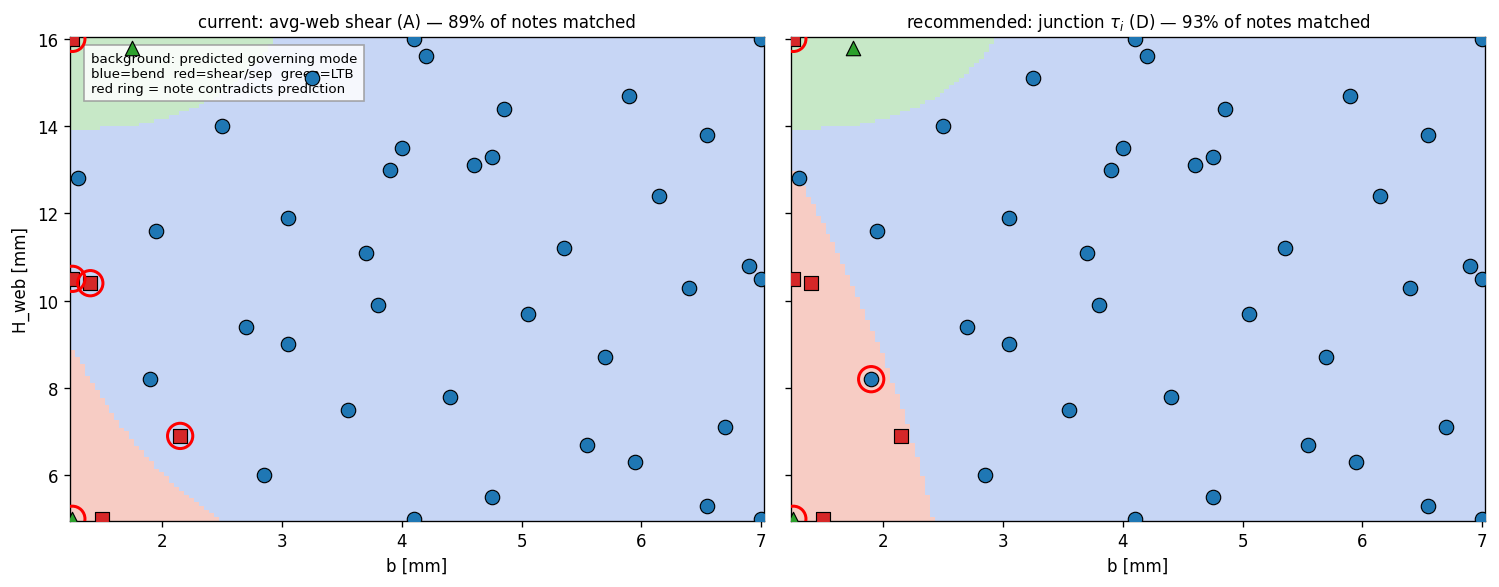

In [10]:
bg, Hg = np.linspace(1.25, 7.0, 140), np.linspace(5.0, 16.0, 130)
BB, HH = np.meshgrid(bg, Hg)
from matplotlib.colors import ListedColormap
MODE_ID = {"bend": 0, "sep": 1, "LTB": 2}
MODE_BG = ListedColormap([(0.78, 0.84, 0.96), (0.97, 0.80, 0.77), (0.78, 0.91, 0.78)])
OBS_MK = {"bend": "o", "flange_web_sep": "s", "LTB": "^"}

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0), sharey=True)
for ax, fn, name, okcol in [(axes[0], gov_old, "current: avg-web shear (A)", "ok_old"),
                            (axes[1], gov_new, "recommended: junction $\\tau_i$ (D)", "ok_new")]:
    gov = np.array([MODE_ID[fn(b, H)[1]] for b, H in
                    zip(BB.ravel(), HH.ravel())]).reshape(BB.shape)
    ax.pcolormesh(BB, HH, gov, cmap=MODE_BG, vmin=0, vmax=2, shading="auto", rasterized=True)
    for m, mk in OBS_MK.items():
        g = camp[camp.obs_mode == m]
        ax.scatter(g.b_mm, g.H_web_mm, c=COL[m], marker=mk, s=75, edgecolor="k",
                   lw=0.7, zorder=4)
    miss = camp[~camp[okcol]]
    ax.scatter(miss.b_mm, miss.H_web_mm, facecolor="none", edgecolor="red", s=230,
               lw=1.8, zorder=5)
    ax.set_xlabel("b [mm]")
    ax.set_title(f"{name} — {100*camp[okcol].mean():.0f}% of notes matched", fontsize=10)
axes[0].set_ylabel("H_web [mm]")
axes[0].text(0.03, 0.97, "background: predicted governing mode\nblue=bend  red=shear/sep  green=LTB\nred ring = note contradicts prediction",
             transform=axes[0].transAxes, fontsize=8, va="top",
             bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.6"))
plt.tight_layout(); plt.show()

89% → 93%, and — more important than the count — the three remaining misses
are all *understood*: print 3 (LTB sets the load, separation is the crack
path), print 1 (fixture tip-off at interface-capacity load), print 14 (mixed
mode sitting just under $\tau_i$; the model calls it separation, the crack
arrived as both). The current model's misses were unexplained: four
separations it placed safely in bend/LTB territory with no mechanism to ever
get them right, at any recalibration.

Strength accuracy on the beams that actually separated:

In [11]:
rows = []
for _, r in sep.iterrows():
    co, _ = gov_old(r.b_mm, r.H_web_mm); cn, _ = gov_new(r.b_mm, r.H_web_mm)
    rows.append(dict(print_order=r.print_order, measured_N=r.strength_N,
                     old_pred=round(co), new_pred=round(cn),
                     old_ratio=round(r.strength_N/co, 2), new_ratio=round(r.strength_N/cn, 2)))
print(pd.DataFrame(rows).to_string(index=False))
print("\n(ratio = measured/predicted; print 3 is LTB-governed under both models)")

r_old = np.array([r["old_ratio"] for r in rows if r["print_order"] != 3])
r_new = np.array([r["new_ratio"] for r in rows if r["print_order"] != 3])
print(f"clean separations: old worst error {100*np.abs(r_old-1).max():.0f}%  "
      f"new worst error {100*np.abs(r_new-1).max():.0f}%")

 print_order  measured_N  old_pred  new_pred  old_ratio  new_ratio
           3       226.2       328       328       0.69       0.69
           9       701.0       711       656       0.99       1.07
          30       865.2       815      1009       1.06       0.86
          40       790.0       561       668       1.41       1.18
          44       654.6       743       734       0.88       0.89

(ratio = measured/predicted; print 3 is LTB-governed under both models)
clean separations: old worst error 41%  new worst error 18%


One trade-off to disclose: on the *bend* population the old pipeline's
median measured/predicted is ≈0.91 versus ≈0.87 for a plain
min($P_{bend}$, $P_D$, $P_{LTB}$) — the inverse-square interaction has been
quietly compensating for bulk-$\sigma_y$ flexure over-prediction. That bias
belongs to the *bending* model (calibrating $\sigma_y$, which the student
flow already does) — not to a shear term computed on the wrong plane. If the
interaction form is kept for continuity, $\tau_i$ must be recalibrated
jointly with it; as calibrated here it assumes the plain-minimum form.

## 8. The later batches are the honest validation

The follow-up batch (19 beams, notebook 15) and the interleaved support
experiment (10 beams at b = 1.3, H = 12.8, notebook 17) were printed in
different sessions, partly with corrected support settings. They test the
calibration out-of-sample:

In [12]:
def note_mode(s):
    s = str(s).lower()
    if "flipped" in s or "twisted" in s or "buckling" in s: return "LTB"
    has_sep = "seperat" in s or "separat" in s          # seperation / seperated
    has_vert = "vertical crack" in s or "vertical fracture" in s
    return "sep" if (has_sep and not has_vert) else ("mixed" if has_sep else "bend")

add["tag"] = add.tag.fillna("")
add["mode"] = add.failure_note.map(note_mode)
add["tau_j"] = [implied_taus(r.b, r.H, r.strength_N)[2] for _, r in add.iterrows()]
print("follow-up batch — junction stress at failure (MPa):")
print(add[["b", "H", "tag", "strength_N", "tau_j", "mode"]]
      .sort_values(["mode", "b"]).round(2).to_string(index=False))

sup["mode"] = sup.failure_note.map(note_mode)
sup["tau_j"] = [implied_taus(r.b, r.H, r.strength_N)[2] for _, r in sup.iterrows()]
print("\nsupport experiment (all b=1.3, H=12.8, one session):")
print(sup[["supports", "rep", "strength_N", "tau_j", "mode"]].round(2).to_string(index=False))

v_sep = add.loc[add["mode"] == "sep", "tau_j"].tolist() + \
        sup.loc[sup["mode"] == "sep", "tau_j"].tolist()
print(f"\nclean separations, later batches: tau_j = "
      f"{', '.join(f'{v:.1f}' for v in sorted(v_sep))} MPa "
      f"(campaign calibration was {TAU_I/1e6:.1f})")

follow-up batch — junction stress at failure (MPa):
   b     H tag  strength_N  tau_j  mode
1.74 14.88  PS       376.1   5.35   LTB
1.74 14.88  S1       383.8   5.46   LTB
1.74 14.88  S2       414.4   5.89   LTB
1.10 12.50           540.7  15.11  bend
1.30 12.80  S1       565.2  13.03  bend
1.30 12.80  S2       566.1  13.05  bend
1.30 12.80  S3       553.0  12.75  bend
2.05 10.10  PS       660.2  10.70  bend
2.55 10.80           728.9   9.08  bend
2.70  9.40  S1       782.5   9.80  bend
2.70  9.40  S2       787.3   9.86  bend
2.70  9.40  S3       801.8  10.04  bend
3.10 13.20           673.5   5.75  bend
1.00 10.00           669.6  22.81 mixed
2.05 10.10           747.5  12.11 mixed
1.00 12.50           475.0  14.67   sep
1.25 13.40  S1       470.8  10.95   sep
1.25 13.40  S2       500.8  11.65   sep
1.30 12.80  PS       524.2  12.09   sep

support experiment (all b=1.3, H=12.8, one session):
supports  rep  strength_N  tau_j  mode
  proper    1       568.9  13.12  bend
  proper    2   

Three findings, one message:

* **The geometry scaling holds out-of-sample.** Every later separation
  back-calculates to 11–15 MPa — the same order, nothing like the 22–53 MPa
  spread Model A needs — across three geometries the calibration never saw.
* **The strength level drifts with print quality.** Later sessions separate
  at 11–15 MPa vs the campaign's 15–21. The support experiment shows why
  this is real physics, not noise: at one geometry in one session, all five
  proper-support beams failed in bending (568–576 N, 1% scatter) while
  three of five improper-support beams showed separation — one clean at an
  implied 11.9 MPa, two mixed with vertical cracking at 11.4–12.6 (the
  495 N low-tail beam among them). $\tau_i$ is a property of the printed
  joint, and print quality *is* a variable of the joint.
* **The mode boundary genuinely overlaps.** Campaign print 18 (b = 1.3,
  H_web = 12.8) carried 12.7 MPa in bending; its proper-support reprints carried
  13.0–13.3 in bending; its improper-support reprints separated at
  11.4–11.9. Near the boundary, which mode you get is partly the
  print-quality draw — no deterministic map can be exact there, and the
  correct classroom statement is probabilistic.

For a single number, the campaign value $\tau_i = 17.5$ MPa is the right
calibration for campaign-condition prints; pooling all nine clean
separations across batches gives ≈14.6 MPa with CoV ≈ 23%. We recommend carrying $\tau_i$
**with its scatter** (17.5 ± 2.7 within-campaign; 11–21 across sessions)
rather than as a constant — it is the single most uncertainty-bearing
parameter in the physics layer, which is exactly the kind of parameter this
course is about.

## 8b. The LTB–separation blur, quantified

A fair objection to the calibration: separation and LTB are not independent
modes on independent planes — twist loads the flange–web joint in *peeling*,
so an LTB-adjacent beam might separate below its pure-shear capacity,
dragging $\tau_i$ down with it. If the implied $\tau_j$ fell systematically
with LTB proximity, the calibration would be confounded. The metric below is
**P/Pcr**: measured failure load over the *elastic* LTB load (uncapped
$M_{cr}$, k = 0.33). One caveat on the metric itself: the LTB model
over-predicts the confirmed LTB-corner failures by 20–31%, so these margins
are optimistic in absolute terms; the relative comparisons are what carry
the argument.

In [ ]:
def P_LTB_elastic(b, H, k=K_FIX):            # uncapped Mcr: no yield ceiling
    p = section_props(b, H)
    Lb, zg = k * L_SPAN/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2 * G_MOD * p["J"])/(np.pi**2 * E_MOD * p["Iy"]) + (C2_LTB*zg)**2
    Mcr = C1_LTB * np.pi**2 * E_MOD * p["Iy"]/Lb**2 * (np.sqrt(R) - C2_LTB*zg)
    return 4 * Mcr / (L_SPAN/1e3)

rows = [(f"print {r.print_order}", r.b_mm, r.H_web_mm, r.strength_N, r.tau_j,
         {"flange_web_sep": "sep"}.get(r.obs_mode, r.obs_mode))
        for _, r in camp[camp.obs_mode != "bend"].iterrows()]
rows += [(f"follow-up {r.tag or 'single'}", r.b, r.H, r.strength_N, r.tau_j, r["mode"])
         for _, r in add[add["mode"].isin(["sep", "LTB"])].iterrows()]
rows += [(f"support {r.supports} r{r.rep}", r.b, r.H, r.strength_N, r.tau_j, r["mode"])
         for _, r in sup[sup["mode"] == "sep"].iterrows()]

print(f"{'beam':<22} {'b':>5} {'H':>5} {'P [N]':>6} {'tau_j':>6} {'P/Pcr':>6}  mode")
recs = []
for name, b, H, P, tj, mode in rows:
    m = P / P_LTB_elastic(b, H)
    recs.append((name, mode, tj, m))
    print(f"{name:<22} {b:>5.2f} {H:>5.1f} {P:>6.0f} {tj:>6.1f} {m:>6.2f}  {mode}")

clean = [(t, m) for n, md, t, m in recs if md == "sep" and n != "print 3"]
tj_all, pr_all = map(np.array, zip(*clean))
c4 = [(t, m) for n, md, t, m in recs
      if md == "sep" and n.startswith("print") and n != "print 3"]
tj4, pr4 = map(np.array, zip(*c4))
print(f"\ncorr(tau_j, P/Pcr) over all {len(clean)} clean separations: "
      f"{np.corrcoef(pr_all, tj_all)[0,1]:+.2f}")
print(f"within the campaign four alone:                   "
      f"{np.corrcoef(pr4, tj4)[0,1]:+.2f}  (n = 4)")

print("\ntau_i under stability sub-selection (campaign seps, most stable first):")
o = np.argsort(pr4)
for n_keep in (2, 3, 4):
    v = tj4[o][:n_keep]
    print(f"  {n_keep} most stable (P/Pcr <= {pr4[o][n_keep-1]:.2f}): "
          f"tau_i = {v.mean():5.2f} MPa   (SE {v.std(ddof=1)/np.sqrt(n_keep):.2f})")

beam                       b     H  P [N]  tau_j  P/Pcr  mode
print 1                 1.25   5.0    641   20.1   0.22  LTB
print 3                 1.25  16.0    226    4.1   0.69  sep
print 9                 1.25  10.5    701   18.7   0.53  sep
print 30                2.15   6.9    865   15.0   0.37  sep
print 35                1.75  15.8    314    3.9   0.80  LTB
print 40                1.50   5.0    790   20.6   0.27  sep
print 44                1.40  10.4    655   15.6   0.48  sep
follow-up single        1.00  12.5    475   14.7   0.53  sep
follow-up S1            1.25  13.4    471   10.9   0.63  sep
follow-up S2            1.25  13.4    501   11.6   0.67  sep
follow-up PS            1.30  12.8    524   12.1   0.61  sep
follow-up PS            1.74  14.9    376    5.3   0.71  LTB
follow-up S1            1.74  14.9    384    5.5   0.72  LTB
follow-up S2            1.74  14.9    414    5.9   0.78  LTB
support improper r2     1.30  12.8    515   11.9   0.60  sep

corr(tau_j, P/Pcr) ove

Pooled across all nine clean separations the anticorrelation is strong
(r = −0.82) — and it is almost entirely an alias. Slenderness is confounded
with print session: the later batches only ever separated at tall-thin
geometries. Three comparisons pull the effects apart:

* **Matched margin, different session.** Print 9 and the follow-up
  (1.0, 12.5) probe both failed at P/Pcr = 0.53, yet imply 18.7 vs
  14.7 MPa — the session moves $\tau_j$ by ~4 MPa at fixed twist margin.
* **Matched session, varying margin.** Within the campaign four, P/Pcr
  doubles (0.27 → 0.53) with no downward trend — the most stable beam is
  the *highest* $\tau_j$.
* **The controlled experiment (§8).** Same geometry, same session, same
  margin: support quality alone flips the mode.

So the cross-batch drift is print quality wearing slenderness as a costume.
The blur is real only at the extreme: print 3, print 35, and the follow-up
LTB trio form one family at $\tau_j \approx$ 4–6 MPa — the LTB signature on
the junction plane, not a weak interface (if the joint failed at 4 MPa, the
15–21 MPa separations could not exist).

Consequences for the calibration: the four calibration beams sit at
P/Pcr = 0.27–0.53 (twist amplification $1/(1-P/P_{cr}) \le 2.1$), and the
sub-selection check above shows any stability cutoff moves $\tau_i$ by
< 0.4 MPa while up to doubling its standard error — so we keep all four. If
residual twist assist is present at all it biases $\tau_i$ *low*, the
conservative direction for stable designs. The un-conservative territory is
the corner itself, which this physics lane assigns to LTB; the GT notebook
(§5) demonstrates that the GP layer *learns* the corner knockdown
out-of-sample (leave-location-out error within ±16% where the plain physics
min over-predicts by 25–45%). Division of labor: the hand calculation stays
a clean min(), the ML layer owns the mode interaction, and the residual
mode-boundary randomness is stated as probability. The clean de-aliasing
experiment stays on the wishlist: reprint a stubby separation-prone geometry
(print 40's b = 1.5, H = 5) in a later session with improper supports —
$\tau_j \approx$ 11–12 MPa says session, ≈ 15+ says twist.

## 9. Recommendation, caveats, consequences

**Adopt Model D.** Replace `P_shear = 2(σy/√3)·t_w·h_w` with

$$P_{sep} = 2\,\tau_i\,\frac{I_x\,t_w}{Q_f},\qquad
Q_f = B\,t_f\,\frac{h_w+t_f}{2},\qquad \tau_i = 17.5\ \text{MPa (campaign)}$$

and treat governing capacity as min($P_{bend}$, $P_{sep}$, $P_{LTB}$).

**Why we believe it** — one line per test: right plane (the notes); constant
implied strength (CoV 15% vs 41%); zero violations among 37 bend beams with
boundary cases at the boundary; near-elastic traces at peak; mode match
89 → 93% with explained misses; worst separation-beam strength error
41 → 18%; geometry scaling confirmed on three out-of-sample geometries; and
the genuine pointwise von Mises alternative fails the population test —
18 of 37 bend beams would violate its calibrated envelope (Section 5).

**Caveats we are carrying, openly:**
* $\tau_i$ rests on 4 clean campaign separations (+4 later ones); the 93%
  match rate is scored in-sample. More thin-web tests would tighten it.
* $\tau_i$ drifts with print session and support quality (11–21 MPa
  observed). It should be stated as a distribution; near the bend/sep
  boundary the observed mode is genuinely stochastic.
* The LTB–separation coupling in the tall-thin corner (print 3) is real and
  unmodeled *in this physics lane*: LTB twist can peel the interface below
  $P_{sep}$. Section 8b shows the calibration is insulated from it ($\tau_i$
  moves < 0.4 MPa under stability sub-selection, no twist trend
  within-session), and the GT notebook shows its GP layer learns the corner
  knockdown from the five LTB-family beams. The hand-calc lane models that
  corner as LTB and says so.
* Bulk-yield flexure over-predicts bend strength ~13% median; the old
  interaction surrogate was masking this. It should be fixed where it lives
  (calibrated $\sigma_y$), not by keeping the old shear term.
* Published interlaminar shear strengths for FDM PLA are commonly reported
  in the ~10–25 MPa range, consistent with $\tau_i$ here — verify specific
  citations before quoting in student-facing material.

**Downstream consequences if adopted** (flagged, not yet executed):
`P_shear`/`P_int` in `ibeam150_common.py` and the student Pre-lab 1 physics
lane change; the calibration parameter $c_s$ becomes the physically
meaningful $\tau_i$; the physics features feeding the GT model
(`gpf_sw_matern`) change, so the GT selection must be re-run and the frozen
class numbers re-checked; failure-mode maps and Pre-lab figures regenerate.
The class-default *student* lane (plain GP on str/w) is untouched.

**The teaching upside** is that the winning model is a hand calculation —
$VQ/It$ shear flow is already in the ME 323 syllabus — but its strength
parameter cannot come from any handbook: it is a property of *our printer,
our material, our support settings*, measurable only by breaking beams. That
is the thesis of this module, delivered by the physics itself.

---
*Provenance: campaign data `data/ground_truth_B10_L150.csv` +
`data/ibeam150_campaign_notes.csv` (44 beams, print 23 = recovered trace);
follow-up `data/ibeam150_additional_tests.csv` (19); support experiment
`data/ibeam150_support_experiment.csv` (10); traces
`data/ibeam150_traces_downsampled.csv` (rise + 0.5 mm tail, ≤130 pts/beam,
slope features verified against full traces to <1%). Physics constants
identical to `ibeam150_common.py` and the student notebooks (SY = 76 MPa,
E = 2.5 GPa, C1 = 1.35, C2 = 0.55, k = 0.33). Full-resolution analysis:
`me323/ibeam150_analysis/` notebooks 06, 15, 17.*